In [1]:
# Imports
import os
import sys
from IPython.display import display
from py_scripts.music_utils import parse_files

# Configuration
FILTER_ZERO_DURATION = True
ADJUST_FRACTIONAL_DURATION = True
PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'
SHOW_MEASURE_LINES = True   # draw red vertical lines at measure starts
DISPLAY_PREVIEW = True
PREVIEW_ROWS = 20
CLEANUP_REMOTE = True       # if source is a URL, delete temp file after parsing
RETURN_PLOTS = False        # include plot objects in results under 'plot'

# List of file sources (URLs or local paths)
FILE_SOURCES = [
    'https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml',
    'https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn'
]

# Parse and visualize
results, dfs_by_name, df_processed = parse_files(
    FILE_SOURCES,
    filter_zero_duration=FILTER_ZERO_DURATION,
    adjust_fractional_duration=ADJUST_FRACTIONAL_DURATION,
    backend=PLOTTING_BACKEND,
    show_measure_lines=SHOW_MEASURE_LINES,
    display_preview=DISPLAY_PREVIEW,
    preview_rows=PREVIEW_ROWS,
    cleanup_remote=CLEANUP_REMOTE,
    return_plots=RETURN_PLOTS,
)

# Show quick summary
print('Parsed DataFrames:')
for item in results:
    name = item['name']
    df = item['df']
    pos_dur = df.loc[df['Duration'] > 0, 'Duration'] if 'Duration' in df.columns else None
    min_dur_str = str(float(pos_dur.min())) if pos_dur is not None and len(pos_dur) > 0 else 'n/a'
    print(f"- {name}: rows={len(df)}, unique_pitches={df['MIDI'].nunique()}, min_duration={min_dur_str}")


Processing: PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml -> 00_prjode_jos0302_com_1_5_missadapac_002_00006


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI
0,1,0.0,0.0,8.0,G3,55
1,1,8.0,8.0,4.0,F3,53
2,2,0.0,12.0,8.0,G4,67
3,2,0.0,12.0,3.0,G3,55
4,2,3.0,15.0,1.0,A3,57
5,2,4.0,16.0,2.0,B-3,58
6,2,6.0,18.0,2.0,G3,55
7,2,8.0,20.0,4.0,F4,65
8,2,8.0,20.0,4.0,A3,57
9,3,0.0,24.0,3.0,G4,67


Rows: 797, unique pitches: 24
Processing: wtc1f04.krn -> 01_wtc1f04


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI
0,1,0.0,0.0,4.0,C#3,49
1,2,0.0,4.0,2.0,B#2,48
2,2,2.0,6.0,2.0,E3,52
3,3,0.0,8.0,4.0,D#3,51
4,4,0.0,12.0,4.0,G#3,56
5,4,0.0,12.0,1.0,C#3,49
6,4,1.0,13.0,1.0,D#3,51
7,4,2.0,14.0,2.0,E3,52
8,5,0.0,16.0,2.0,F##3,55
9,5,0.0,16.0,1.0,E3,52


Rows: 1429, unique pitches: 45
Parsed DataFrames:
- 00_prjode_jos0302_com_1_5_missadapac_002_00006: rows=797, unique_pitches=24, min_duration=0.5
- 01_wtc1f04: rows=1429, unique_pitches=45, min_duration=0.5


list all parsed dfs:

In [2]:
list(dfs_by_name)

['00_prjode_jos0302_com_1_5_missadapac_002_00006', '01_wtc1f04']

select one parsed df from list:

In [3]:
df0 = results[0]['df']
measure_offsets0 = results[0]['measure_offsets']

display(df0)

,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI
0,1,0.0,0.0,8.0,G3,55
1,1,8.0,8.0,4.0,F3,53
2,2,0.0,12.0,8.0,G4,67
3,2,0.0,12.0,3.0,G3,55
4,2,3.0,15.0,1.0,A3,57
...,...,...,...,...,...,...
792,63,11.0,667.0,1.0,E4,64
793,64,0.0,668.0,12.0,G4,67
794,64,0.0,668.0,12.0,D4,62
795,64,0.0,668.0,12.0,G3,55


save df as tsv:

In [4]:
# import os
# from datetime import datetime

# # Define the path for the /tsv subfolder
# output_directory = 'tsv'

# # Check if the directory exists; if not, create it
# if not os.path.exists(output_directory):
#     os.makedirs(output_directory)

# # Define the filename path to save inside the /tsv subfolder
# filename = os.path.join(output_directory, 'test.tsv')

# try:
#     df0.to_csv(filename, sep='\t', index=False)
#     print(f"Data saved successfully to {os.path.abspath(filename)} at {datetime.now()}.")
# except:
#     print("Error: data could not be saved.")


In [5]:
# Verovio visualization helpers
import verovio
from IPython.display import SVG, display
import requests
import json

# Keep a single toolkit instance per session
_vrv_toolkit = verovio.toolkit()


def _vrv_ensure_svg(svg):
    if svg is None:
        return ""
    if isinstance(svg, bytes):
        return svg.decode('utf-8', errors='ignore')
    return svg


def vrv_set_options(**kwargs):
    """Set Verovio options with sensible defaults for notebook viewing."""
    defaults = {
        # Large width and no line breaks → long horizontal system
        "pageWidth": 8000,
        "pageHeight": 1000,
        "scale": 50,
        "breaks": "none",  # prevent system/page breaks
        "svgBoundingBoxes": True,
        "adjustPageHeight": True,
    }
    opts = {**defaults, **kwargs}
    _vrv_toolkit.setOptions(opts)


def vrv_load_from_url(url: str, input_from: str = None):
    """Load MEI/MusicXML/Kern from URL into Verovio."""
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.text
    if input_from:  # e.g., "musicxml", "mei", "humdrum"
        _vrv_toolkit.setOptions({"inputFrom": input_from})
    _vrv_toolkit.loadData(data)
    return _vrv_toolkit.getPageCount()


def vrv_render_all_pages():
    pages = _vrv_toolkit.getPageCount()
    svgs = []
    for p in range(1, pages + 1):
        svg = _vrv_toolkit.renderToSVG(p)
        svgs.append(_vrv_ensure_svg(svg))
    return svgs


def vrv_display_svg(svg: str, width: str = "100%", height: str = "auto"):
    """Display a single SVG with notebook-friendly sizing."""
    display(SVG(_vrv_ensure_svg(svg)))


def vrv_find_elements_at_time(ms: float):
    """Return elements that sound at the given time in milliseconds.
    Requires a time map created by renderToTimemap.
    """
    return _vrv_toolkit.getElementsAtTime(ms) if hasattr(_vrv_toolkit, "getElementsAtTime") else None


def vrv_timemap():
    """Return the timing map for the current layout (list of time-aligned events)."""
    if hasattr(_vrv_toolkit, "renderToTimemap"):
        tm = _vrv_toolkit.renderToTimemap()
        try:
            return json.loads(tm) if isinstance(tm, str) else tm
        except Exception:
            return tm
    return None


### Verovio: render parsed file as horizontal, scrollable score
The following cell loads the currently parsed file URL and renders it as a single long horizontal system using Verovio. Adjust `pageWidth`, `scale`, or `breaks` as desired.


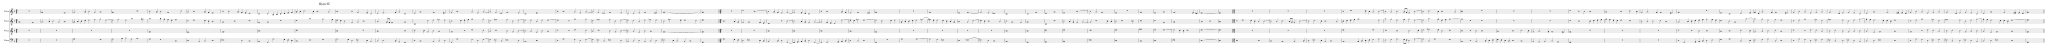

In [6]:
# Horizontal scroll render for the first parsed source
# Choose the first file source defined above (already used by parse_files)
url0 = FILE_SOURCES[0]

# MusicXML input: the Weimar URL is .xml (MusicXML)
vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none")
_ = vrv_load_from_url(url0, input_from="musicxml")
svgs = vrv_render_all_pages()

# Display inside a horizontally scrollable output cell (Jupyter will scroll if width exceeds)
for svg in svgs:
    vrv_display_svg(svg)


### Verovio: highlighting demos
Below are multiple approaches you can compare:
- By element IDs: color specific note elements in the SVG.
- By time range: compute elements sounding within a time window using the timemap API.
- By measures: re-render a selected measure range if selection is supported.

Note: Verovio Python returns plain SVG; we can post-process the SVG string to add highlight styles.


In [7]:
from typing import Dict, Iterable, List, Optional, Tuple, Union
import json
import math
import re
import xml.etree.ElementTree as ET

HIGHLIGHT_CSS = '''
<style>
.note-highlight { fill: #ff4d4f !important; stroke: #aa2222 !important; }
.note-highlight-2 { fill: #40a9ff !important; stroke: #1d39c4 !important; }
.measure-highlight { fill-opacity: 0.15 !important; }
.measure-overlay-group { pointer-events: none; }
.measure-overlay { fill: #ffd666; fill-opacity: 0.28; stroke: #d48806; stroke-opacity: 0.6; rx: 6; ry: 6; pointer-events: none; }
</style>
'''.strip()

SVG_NS = "{http://www.w3.org/2000/svg}"


# ---------------------------------------------------------------------------
# SVG helpers
# ---------------------------------------------------------------------------

def _coerce_svg(svg: Union[str, bytes, None]) -> str:
    if svg is None:
        return ""
    if isinstance(svg, bytes):
        return svg.decode("utf-8", errors="ignore")
    return str(svg)


def inject_css(svg: Union[str, bytes]) -> str:
    """Insert notebook CSS hooks into the SVG (idempotent)."""
    svg = _coerce_svg(svg)
    if not svg:
        return svg
    if HIGHLIGHT_CSS in svg:
        return svg
    return re.sub(r"(<svg[^>]*>)", lambda m: m.group(1) + "\n" + HIGHLIGHT_CSS, svg, count=1, flags=re.IGNORECASE)


# ---------------------------------------------------------------------------
# Measure parsing
# ---------------------------------------------------------------------------

def _normalise_measure_label(label: Optional[Union[str, int]]) -> Optional[int]:
    if label is None:
        return None
    if isinstance(label, int):
        return label if label > 0 else None
    text = str(label).strip()
    if not text:
        return None
    if text.isdigit():
        value = int(text)
        return value if value > 0 else None
    match = re.search(r"(\d+)$", text)
    if match:
        value = int(match.group(1))
        return value if value > 0 else None
    return None


def _expand_piece(piece: Union[str, int, float]) -> Iterable[int]:
    if isinstance(piece, (int, float)):
        value = int(piece)
        if value > 0:
            yield value
        return
    text = str(piece).strip()
    if not text:
        return
    if '-' in text:
        start, end = text.split('-', 1)
        try:
            start_i = int(start.strip())
            end_i = int(end.strip())
        except ValueError:
            return
        if start_i > end_i:
            start_i, end_i = end_i, start_i
        for value in range(start_i, end_i + 1):
            if value > 0:
                yield value
    else:
        try:
            value = int(text)
        except ValueError:
            return
        if value > 0:
            yield value


def _parse_measure_spec(spec: Optional[Union[str, Iterable[Union[str, int, float]]]]) -> List[int]:
    if spec is None:
        return []
    if isinstance(spec, (list, tuple, set)):
        pieces: Iterable[Union[str, int, float]] = spec
    else:
        pieces = [chunk.strip() for chunk in str(spec).split(',') if chunk.strip()]
    measures: List[int] = []
    seen: set[int] = set()
    for piece in pieces:
        for value in _expand_piece(piece):
            if value not in seen:
                measures.append(value)
                seen.add(value)
    return measures


# ---------------------------------------------------------------------------
# Geometry helpers
# ---------------------------------------------------------------------------

def _matrix_identity() -> Tuple[float, float, float, float, float, float]:
    return (1.0, 0.0, 0.0, 1.0, 0.0, 0.0)


def _matrix_multiply(m1: Tuple[float, float, float, float, float, float], m2: Tuple[float, float, float, float, float, float]) -> Tuple[float, float, float, float, float, float]:
    a1, b1, c1, d1, e1, f1 = m1
    a2, b2, c2, d2, e2, f2 = m2
    return (
        a1 * a2 + c1 * b2,
        b1 * a2 + d1 * b2,
        a1 * c2 + c1 * d2,
        b1 * c2 + d1 * d2,
        a1 * e2 + c1 * f2 + e1,
        b1 * e2 + d1 * f2 + f1,
    )


def _matrix_from_transform(transform: Optional[str]) -> Tuple[float, float, float, float, float, float]:
    if not transform:
        return _matrix_identity()
    matrix = _matrix_identity()
    for match in re.finditer(r"([a-zA-Z]+)\s*\(([^)]*)\)", transform):
        name = match.group(1).lower()
        raw_args = [val for val in re.split(r"[ ,]+", match.group(2).strip()) if val]
        try:
            args = [float(val) for val in raw_args]
        except ValueError:
            continue
        if name == "translate":
            tx = args[0] if args else 0.0
            ty = args[1] if len(args) > 1 else 0.0
            m = (1.0, 0.0, 0.0, 1.0, tx, ty)
        elif name == "scale":
            sx = args[0] if args else 1.0
            sy = args[1] if len(args) > 1 else sx
            m = (sx, 0.0, 0.0, sy, 0.0, 0.0)
        elif name == "matrix" and len(args) == 6:
            m = tuple(args)  # type: ignore[assignment]
        elif name == "rotate":
            angle = math.radians(args[0] if args else 0.0)
            cos_a = math.cos(angle)
            sin_a = math.sin(angle)
            if len(args) >= 3:
                cx, cy = args[1], args[2]
                m = (
                    cos_a,
                    sin_a,
                    -sin_a,
                    cos_a,
                    cx - cos_a * cx + sin_a * cy,
                    cy - sin_a * cx - cos_a * cy,
                )
            else:
                m = (cos_a, sin_a, -sin_a, cos_a, 0.0, 0.0)
        else:
            continue
        matrix = _matrix_multiply(matrix, m)
    return matrix


def _build_parent_map(root: ET.Element) -> Dict[ET.Element, Optional[ET.Element]]:
    parent_map: Dict[ET.Element, Optional[ET.Element]] = {root: None}
    stack = [root]
    while stack:
        node = stack.pop()
        for child in list(node):
            parent_map[child] = node
            stack.append(child)
    return parent_map


def _matrix_for_element(element: ET.Element, parent_map: Dict[ET.Element, Optional[ET.Element]]) -> Tuple[float, float, float, float, float, float]:
    chain = []
    current = element
    while current is not None:
        chain.append(current)
        current = parent_map.get(current)
    matrix = _matrix_identity()
    for node in reversed(chain):
        matrix = _matrix_multiply(matrix, _matrix_from_transform(node.attrib.get('transform')))
    return matrix


def _transform_bbox(matrix: Tuple[float, float, float, float, float, float], x: float, y: float, width: float, height: float) -> Tuple[float, float, float, float]:
    points = [
        (x, y),
        (x + width, y),
        (x, y + height),
        (x + width, y + height),
    ]
    a, b, c, d, e, f = matrix
    transformed = [(a * px + c * py + e, b * px + d * py + f) for px, py in points]
    min_x = min(p[0] for p in transformed)
    max_x = max(p[0] for p in transformed)
    min_y = min(p[1] for p in transformed)
    max_y = max(p[1] for p in transformed)
    return min_x, min_y, max_x - min_x, max_y - min_y


def _extract_bbox_from_attrs(attrs: Dict[str, str]) -> Optional[Tuple[float, float, float, float]]:
    bbox_raw = attrs.get('data-bbox') or attrs.get('data-bbox-full')
    if bbox_raw:
        parts = [p for p in re.split(r"[ ,]+", bbox_raw.strip()) if p]
        if len(parts) >= 4:
            try:
                x, y, w, h = map(float, parts[:4])
                return x, y, w, h
            except ValueError:
                pass
    combos = (
        ('data-bbox-x', 'data-bbox-y', 'data-bbox-w', 'data-bbox-h'),
        ('data-ulx', 'data-uly', 'data-lrx', 'data-lry'),
    )
    for keys in combos:
        if all(key in attrs for key in keys):
            try:
                if keys[0] == 'data-ulx':
                    x = float(attrs['data-ulx'])
                    y = float(attrs['data-uly'])
                    w = float(attrs['data-lrx']) - x
                    h = float(attrs['data-lry']) - y
                else:
                    x = float(attrs['data-bbox-x'])
                    y = float(attrs['data-bbox-y'])
                    w = float(attrs['data-bbox-w'])
                    h = float(attrs['data-bbox-h'])
                return x, y, w, h
            except ValueError:
                continue
    if all(key in attrs for key in ('x', 'y', 'width', 'height')):
        try:
            return (
                float(attrs['x']),
                float(attrs['y']),
                float(attrs['width']),
                float(attrs['height']),
            )
        except ValueError:
            return None
    return None


def _find_bbox_in_node(node: ET.Element) -> Optional[Tuple[Tuple[float, float, float, float], ET.Element]]:
    bbox = _extract_bbox_from_attrs(node.attrib)
    if bbox:
        return bbox, node
    for child in node:
        if child.tag == f"{SVG_NS}rect":
            rect_bbox = _extract_bbox_from_attrs(child.attrib)
            if rect_bbox:
                return rect_bbox, child
    return None


def _candidate_nodes_for_measure(element: ET.Element, node_lookup: Dict[str, ET.Element]) -> List[ET.Element]:
    candidates: List[ET.Element] = []
    seen: set[ET.Element] = set()

    def add(node: Optional[ET.Element]):
        if node is not None and node not in seen:
            candidates.append(node)
            seen.add(node)

    add(element)
    measure_id = element.attrib.get('id')
    if measure_id:
        add(node_lookup.get(f'bbox-{measure_id}'))
        add(node_lookup.get(f'bbox-{measure_id}-rect'))
        add(node_lookup.get(f'{measure_id}-bbox'))
    for child in element.findall(f".//{SVG_NS}g"):
        classes = child.attrib.get('class', '').split()
        if 'bounding-box' in classes:
            add(child)
    return candidates


def _extract_measure_data_from_svg(svg: str, padding: float) -> Tuple[List[Dict[str, float]], List[int]]:
    overlays: List[Dict[str, float]] = []
    measures: List[int] = []
    if not svg:
        return overlays, measures
    try:
        root = ET.fromstring(svg)
    except ET.ParseError:
        return overlays, measures

    parent_map = _build_parent_map(root)
    node_lookup: Dict[str, ET.Element] = {}
    for elem in root.iter():
        elem_id = elem.attrib.get('id')
        if elem_id:
            node_lookup[elem_id] = elem

    combined: Dict[int, Dict[str, float]] = {}
    order: List[int] = []
    fallback_counter = 0

    for element in root.findall(f".//{SVG_NS}g"):
        classes = element.attrib.get('class', '').split()
        if 'measure' not in classes or 'bounding-box' in classes:
            continue

        measure_number = _normalise_measure_label(
            element.attrib.get('data-n')
            or element.attrib.get('data-number')
            or element.attrib.get('n')
            or element.attrib.get('label')
        )
        if measure_number is None:
            fallback_counter += 1
            measure_number = fallback_counter

        candidates = _candidate_nodes_for_measure(element, node_lookup)
        min_x = float('inf')
        min_y = float('inf')
        max_x = float('-inf')
        max_y = float('-inf')
        found = False
        for node in candidates:
            bbox_info = _find_bbox_in_node(node)
            if not bbox_info:
                continue
            (x, y, width, height), bbox_node = bbox_info
            matrix = _matrix_for_element(bbox_node, parent_map)
            tx, ty, tw, th = _transform_bbox(matrix, x, y, width, height)
            min_x = min(min_x, tx)
            min_y = min(min_y, ty)
            max_x = max(max_x, tx + tw)
            max_y = max(max_y, ty + th)
            found = True
        if not found:
            continue

        entry = combined.get(measure_number)
        if entry is None:
            combined[measure_number] = {
                'min_x': min_x,
                'min_y': min_y,
                'max_x': max_x,
                'max_y': max_y,
                'label': element.attrib.get('id'),
            }
            order.append(measure_number)
        else:
            entry['min_x'] = min(entry['min_x'], min_x)
            entry['min_y'] = min(entry['min_y'], min_y)
            entry['max_x'] = max(entry['max_x'], max_x)
            entry['max_y'] = max(entry['max_y'], max_y)

    for number in order:
        entry = combined[number]
        min_x = entry['min_x']
        min_y = entry['min_y']
        max_x = entry['max_x']
        max_y = entry['max_y']
        x = max(0.0, min_x - padding)
        y = max(0.0, min_y - padding)
        width = (max_x - min_x) + 2 * padding
        height = (max_y - min_y) + 2 * padding
        overlays.append({
            'measure': number,
            'label': entry['label'] or number,
            'x': x,
            'y': y,
            'width': width,
            'height': height,
        })
        measures.append(number)

    return overlays, measures


def vrv_measure_inventory(padding: float = 12.0) -> Tuple[Dict[int, List[Dict[str, float]]], Dict[int, List[int]]]:
    overlays_by_page: Dict[int, List[Dict[str, float]]] = {}
    measures_by_page: Dict[int, List[int]] = {}

    page_count = _vrv_toolkit.getPageCount()
    use_render_to_page = hasattr(_vrv_toolkit, 'renderToPage')

    for page in range(1, page_count + 1):
        page_overlays: List[Dict[str, float]] = []
        page_measures: List[int] = []

        if use_render_to_page:
            page_data = _vrv_toolkit.renderToPage(page)
            if isinstance(page_data, (bytes, bytearray)):
                page_data = page_data.decode('utf-8', errors='ignore')
            if isinstance(page_data, str):
                try:
                    page_data = json.loads(page_data)
                except json.JSONDecodeError:
                    page_data = None
            if isinstance(page_data, dict):
                for system in page_data.get('systems', []):
                    for measure in system.get('measures', []):
                        label = measure.get('n') or measure.get('number') or measure.get('label') or measure.get('mNo')
                        idx = _normalise_measure_label(label)
                        bbox = measure.get('bbox') or {}
                        x = max(0.0, float(bbox.get('x', 0.0)) - padding)
                        y = max(0.0, float(bbox.get('y', 0.0)) - padding)
                        width = float(bbox.get('w', 0.0)) + 2 * padding
                        height = float(bbox.get('h', 0.0)) + 2 * padding
                        number = idx if idx is not None else len(page_overlays) + 1
                        page_overlays.append({
                            'measure': number,
                            'label': label or number,
                            'x': x,
                            'y': y,
                            'width': width,
                            'height': height,
                        })
                        page_measures.append(number)
        else:
            svg_page = _coerce_svg(_vrv_toolkit.renderToSVG(page))
            svg_overlays, svg_measures = _extract_measure_data_from_svg(svg_page, padding)
            page_overlays.extend(svg_overlays)
            page_measures.extend(svg_measures)

        if page_overlays:
            overlays_by_page[page] = page_overlays
        if page_measures:
            measures_by_page[page] = page_measures

    return overlays_by_page, measures_by_page


def vrv_measure_overlays(measure_spec: Optional[Union[str, Iterable[Union[str, int, float]]]], padding: float = 12.0, *, debug: bool = False) -> Dict[int, List[Dict[str, float]]]:
    measure_numbers = set(_parse_measure_spec(measure_spec))
    overlays_by_page, measures_by_page = vrv_measure_inventory(padding=padding)
    if debug:
        for page, labels in measures_by_page.items():
            print(f"Page {page}: measures discovered → {labels}")
    if not measure_numbers:
        return {page: overlays for page, overlays in overlays_by_page.items() if overlays}

    filtered: Dict[int, List[Dict[str, float]]] = {}
    for page, overlays in overlays_by_page.items():
        matches = [ov for ov in overlays if ov['measure'] in measure_numbers]
        if matches:
            filtered[page] = matches
        elif debug:
            present = [ov.get('measure') for ov in overlays]
            print(f"Page {page}: none of {sorted(measure_numbers)} present; available measures → {present}")
    return filtered


def vrv_apply_measure_overlays(svg: Union[str, bytes], overlays: List[Dict[str, float]], *, fill: str = '#ffd666', opacity: float = 0.28, stroke: Optional[str] = None) -> str:
    svg = _coerce_svg(svg)
    if not overlays or not svg:
        return svg
    stroke = stroke or fill
    rects = []
    for overlay in overlays:
        rects.append(
            (
                '<rect class="measure-overlay" data-measure="{measure}" x="{x:.2f}" y="{y:.2f}" '
                'width="{width:.2f}" height="{height:.2f}" fill="{fill}" fill-opacity="{opacity:.3f}" '
                'stroke="{stroke}" stroke-opacity="{stroke_opacity:.3f}" />'
            ).format(
                measure=overlay.get('measure'),
                x=overlay['x'],
                y=overlay['y'],
                width=overlay['width'],
                height=overlay['height'],
                fill=fill,
                opacity=opacity,
                stroke=stroke,
                stroke_opacity=min(opacity * 1.5, 1.0),
            )
        )
    overlay_group = '<g class="measure-overlay-group">' + ''.join(rects) + '</g>'
    return svg.replace('</svg>', overlay_group + '</svg>', 1)


Page 1: measures discovered → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]


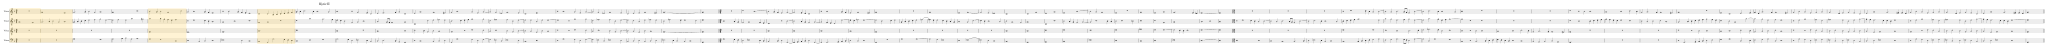

In [11]:
# Demo C: render a measure range (if supported by current toolkit)
try:
    measure_spec = ["1-2", 5, 8]
    overlays_by_page = vrv_measure_overlays(measure_spec, padding=18.0, debug=True)
    page_total = _vrv_toolkit.getPageCount()
    if not overlays_by_page:
        print(f"No overlays generated for measure spec '{measure_spec}'.")

    for page in range(1, page_total + 1):
        svg_page = _vrv_toolkit.renderToSVG(page)
        svg_page = inject_css(svg_page)
        svg_page = vrv_apply_measure_overlays(svg_page, overlays_by_page.get(page, []), fill="#fadb14", opacity=0.22, stroke="#d4b106")
        vrv_display_svg(svg_page)

except Exception as exc:
    print(f"Selection demo failed: {exc}")


In [9]:
# Debug: inspect Verovio measure inventory and bounding boxes
try:
    has_render_to_page = hasattr(_vrv_toolkit, 'renderToPage')
    print(f"Toolkit has renderToPage: {has_render_to_page}")
    print(f"Toolkit has getPageWithElement: {hasattr(_vrv_toolkit, 'getPageWithElement')}")
    svg_sample = _vrv_toolkit.renderToSVG(1)
    if isinstance(svg_sample, bytes):
        svg_sample = svg_sample.decode('utf-8')
    if svg_sample:
        print("SVG sample (first 500 chars):")
        print(svg_sample[:500])
        import xml.etree.ElementTree as ET
        try:
            root = ET.fromstring(svg_sample)
            ns = {'svg': 'http://www.w3.org/2000/svg'}
            measure_attrs = []
            for g in root.findall('.//svg:g', ns):
                classes = g.attrib.get('class', '')
                if 'measure' in classes.split():
                    measure_attrs.append(dict(g.attrib))
                elif 'measure' in classes:
                    measure_attrs.append(dict(g.attrib))
                if len(measure_attrs) >= 5:
                    break
            if measure_attrs:
                print("Sample measure group attributes:")
                for attrs in measure_attrs:
                    print(attrs)
            else:
                print("No <g class='measure'> elements found in parsed SVG.")
        except Exception as parse_exc:
            print(f"Failed to parse SVG for measure groups: {parse_exc}")
    overlays_by_page, measures_by_page = vrv_measure_inventory(padding=18.0)
    if not measures_by_page:
        if has_render_to_page:
            print("renderToPage() did not return any measure metadata. Ensure the score is loaded and rendered first.")
        else:
            print("Measure metadata unavailable (renderToPage missing); using SVG parsing fallback.")
    else:
        print("Measures discovered per page:")
        for page, labels in measures_by_page.items():
            label_preview = ', '.join(str(lbl) for lbl in labels[:25])
            remainder = len(labels) - 25
            suffix = " ..." if remainder > 0 else ""
            print(f"  Page {page}: {label_preview}{suffix}")
        for page, overlays in overlays_by_page.items():
            print()
            print(f"Page {page} overlay candidates ({len(overlays)} total):")
            for ov in overlays:
                label = ov.get('label')
                numeric = ov.get('measure')
                bbox = (ov.get('x'), ov.get('y'), ov.get('width'), ov.get('height'))
                print(f"  label={label} numeric={numeric} bbox={bbox}")
except Exception as exc:
    print(f"Measure inventory dump failed: {exc}")


Toolkit has renderToPage: False
Toolkit has getPageWithElement: True
SVG sample (first 500 chars):
<svg width="15146px" height="357px" version="1.1" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" overflow="visible" id="e4yqncq">
   <desc>Engraved by Verovio 5.6.0[undefined]</desc>
   <defs>
      <g id="E050-e4yqncq">
         <path transform="scale(1,-1)" d="M441 -245c-23 -4 -48 -6 -76 -6c-59 0 -102 7 -130 20c-88 42 -150 93 -187 154c-26 44 -43 103 -48 176c0 6 -1 13 -1 19c0 54 15 111 45 170c29 57 65 106 110 148s96 85 153 127c-3 16 -8 46 -13 92c-4 43 -5 73 -5 89c
Sample measure group attributes:
{'id': 'j1mmghd1', 'class': 'measure'}
{'id': 'bbox-j1mmghd1', 'class': 'measure bounding-box'}
{'id': 'vs9isue', 'class': 'measure'}
{'id': 'bbox-vs9isue', 'class': 'measure bounding-box'}
{'id': 'i1sn8iqj', 'class': 'measure'}
Measures discovered per page:
  Page 1: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25 ...

Pag